In [60]:
import numpy as np
import pandas as pd

df = pd.read_csv("reddit.csv")
df.head()

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1


In [61]:
df.shape

(37249, 2)

In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37249 entries, 0 to 37248
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   clean_comment  37149 non-null  object
 1   category       37249 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 582.1+ KB


In [63]:
df.describe()

,category
count,37249.000000
mean,0.202771
std,0.778515
min,-1.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


In [64]:
df.sample()['clean_comment'].values

array(['where did you get this from '], dtype=object)

In [65]:
df.isnull().sum()

clean_comment    100
category           0
dtype: int64

In [66]:
df.dropna(inplace=True)

In [67]:
df.duplicated().sum()

np.int64(350)

In [68]:
df.drop_duplicates(inplace=True)

In [69]:
df.duplicated().sum()


np.int64(0)

In [70]:
df[(df['clean_comment'].str.strip() == '')]

,clean_comment,category
181,,0
4432,\r\n,0
10592,,0
16173,,0
32149,\r\n,0
34959,,0


In [71]:
df = df[~(df['clean_comment'].str.strip() == '')]

In [72]:
df[(df['clean_comment'].str.strip() == '')]

,clean_comment,category


In [73]:
df['clean_comment'] = df['clean_comment'].str.lower()
df.head()

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1


In [74]:
df[df['clean_comment'].apply(lambda x: x.endswith(' ') or x.startswith(' '))]

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1
...,...,...
37241,let the janta decide not ulema clerics,0
37242,hona hai same with vaccination education insu...,0
37246,downvote karna tha par upvote hogaya,0
37247,haha nice,1


In [75]:
df['clean_comment'] = df['clean_comment'].str.strip()
df['clean_comment'].apply(lambda x: x.endswith(' ') or x.startswith(' ')).sum()

np.int64(0)

In [76]:
comments_with_newline = df[df['clean_comment'].str.contains('\n')]

comments_with_newline.head()

,clean_comment,category
448,what missing jpg\r\nand why this brilliant edi...,1
781,india has been ruined congress and populist sc...,-1
847,like aap for its stand corruption and making p...,-1
871,reduced trade\r\ndeficit stronger rupee aren t...,0
1354,amsa press conference australian maritime safe...,1


In [77]:
df['clean_comment'] = df['clean_comment'].str.replace('\n', ' ', regex = True)

comments_with_newline_remaining = df[df['clean_comment'].str.contains('\n')]
comments_with_newline_remaining

,clean_comment,category


<Axes: xlabel='category', ylabel='count'>

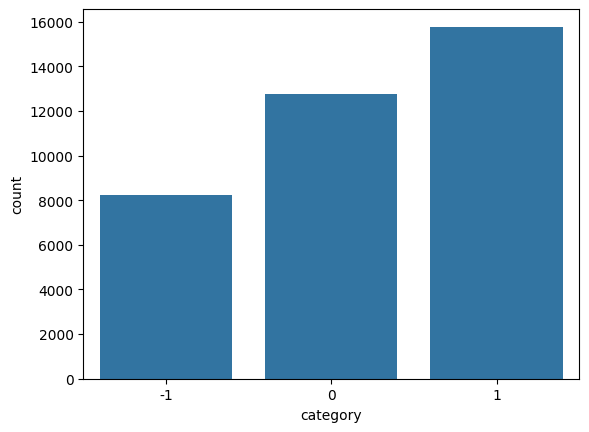

In [78]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x ="category")

In [79]:
df['category'].value_counts(normalize=True).mul(100).round(2)

category
 1    42.86
 0    34.71
-1    22.42
Name: proportion, dtype: float64

In [80]:
df['word_count'] = df['clean_comment'].apply(lambda x: len(x.split()))

In [81]:
df.sample(5)

,clean_comment,category,word_count
11147,need moar,0,2
7968,there some hope for humanity yet american glad...,1,23
11767,you words are exactly right this only the firs...,1,72
26279,big butts cannot lie,0,4
18220,bhaiyya they are back their shitty rhetoric hi...,1,19


In [82]:
df['word_count'].describe()

count    36793.000000
mean        29.667464
std         56.790738
min          1.000000
25%          6.000000
50%         13.000000
75%         30.000000
max       1307.000000
Name: word_count, dtype: float64

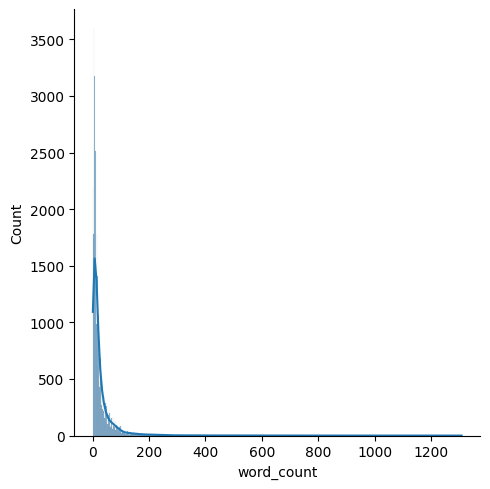

In [83]:
sns.displot(df['word_count'], kde = True)

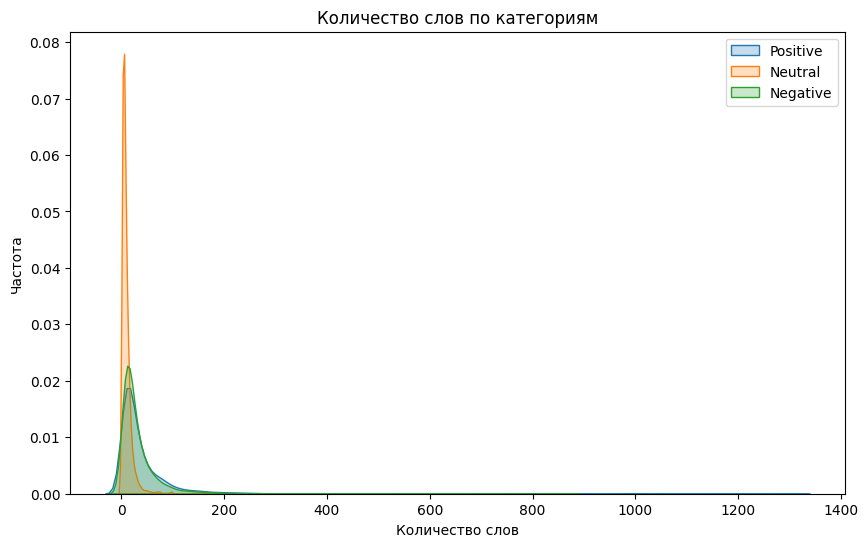

In [84]:
plt.figure(figsize = (10,6))
sns.kdeplot(df[df['category'] == 1]['word_count'], label = 'Positive', fill = True)
sns.kdeplot(df[df['category'] == 0]['word_count'], label = 'Neutral', fill = True)
sns.kdeplot(df[df['category'] == -1]['word_count'], label = 'Negative', fill = True)
plt.title('Количество слов по категориям')
plt.xlabel('Количество слов')
plt.ylabel('Частота')
plt.legend()
plt.show()

<Axes: ylabel='word_count'>

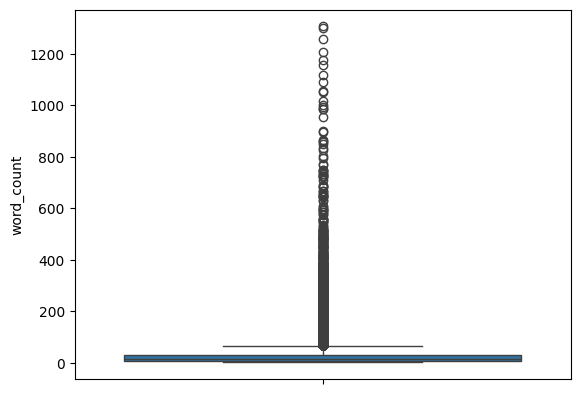

In [85]:
sns.boxplot(df['word_count'])

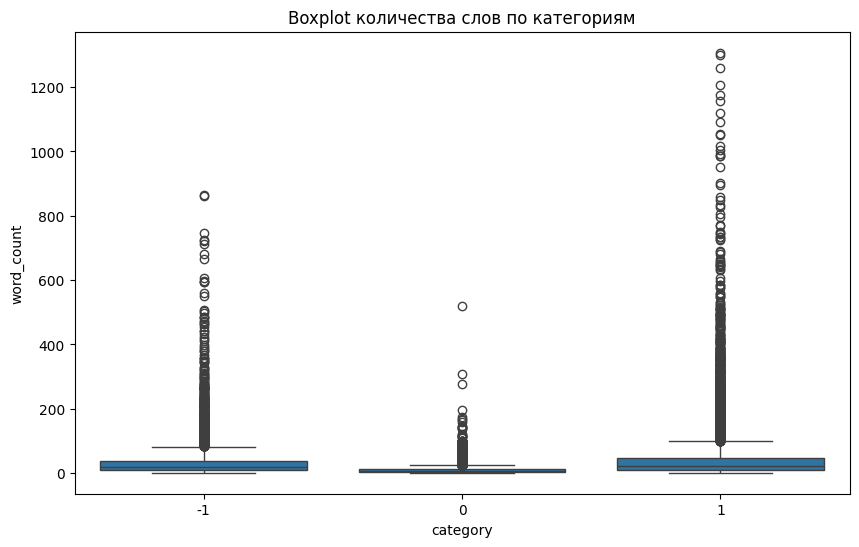

In [86]:
plt.figure(figsize=(10,6))
sns.boxplot(data = df, x = 'category', y = 'word_count')
plt.title('Boxplot количества слов по категориям')
plt.show()

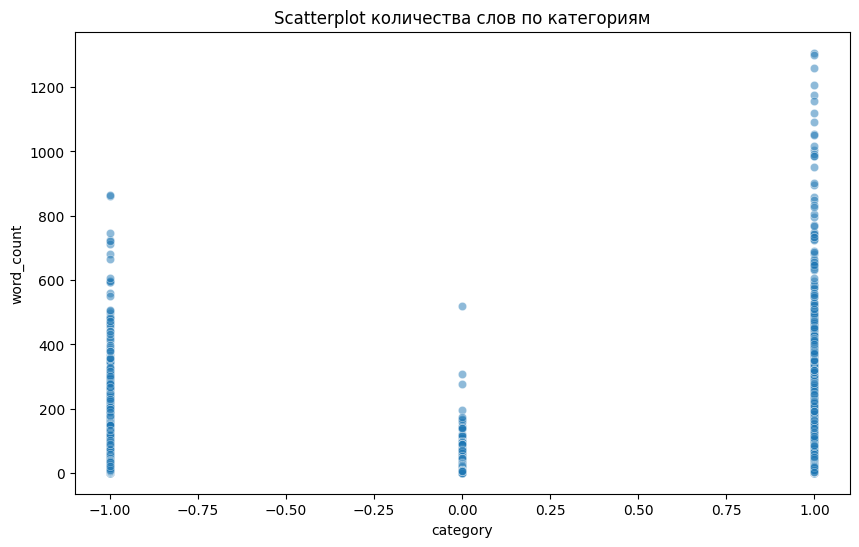

In [87]:
plt.figure(figsize=(10,6))
sns.scatterplot(data = df, x = 'category', y = 'word_count', alpha=0.5)
plt.title('Scatterplot количества слов по категориям')
plt.show()

<Axes: xlabel='category', ylabel='word_count'>

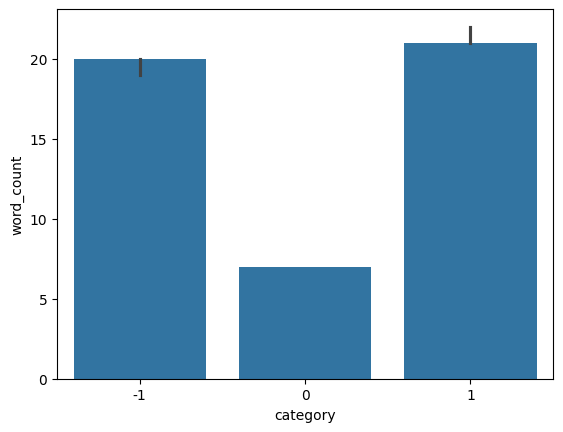

In [88]:
sns.barplot(df, x ='category',y = 'word_count', estimator='median')

In [89]:
!pip install nltk

Defaulting to user installation because normal site-packages is not writeable


In [90]:
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
df['num_stop_words'] = df['clean_comment'].apply(lambda x: len([word for word in x.split() if word in stop_words]))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\iblad\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [91]:
df.sample(5)

,clean_comment,category,word_count,num_stop_words
5069,lol like your enthusiasm for the country but s...,1,58,32
20487,what you want them give him medal party with l...,0,17,8
1549,ahem you only noticed this because the case wa...,1,15,8
36934,they news should pinned for few days shocking,-1,8,4
15515,this whole situation was chronicled through so...,1,12,6


C:\Users\iblad\AppData\Local\Temp\ipykernel_13568\1716895612.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_25_df, x='count', y = 'stop_word', palette = 'viridis')


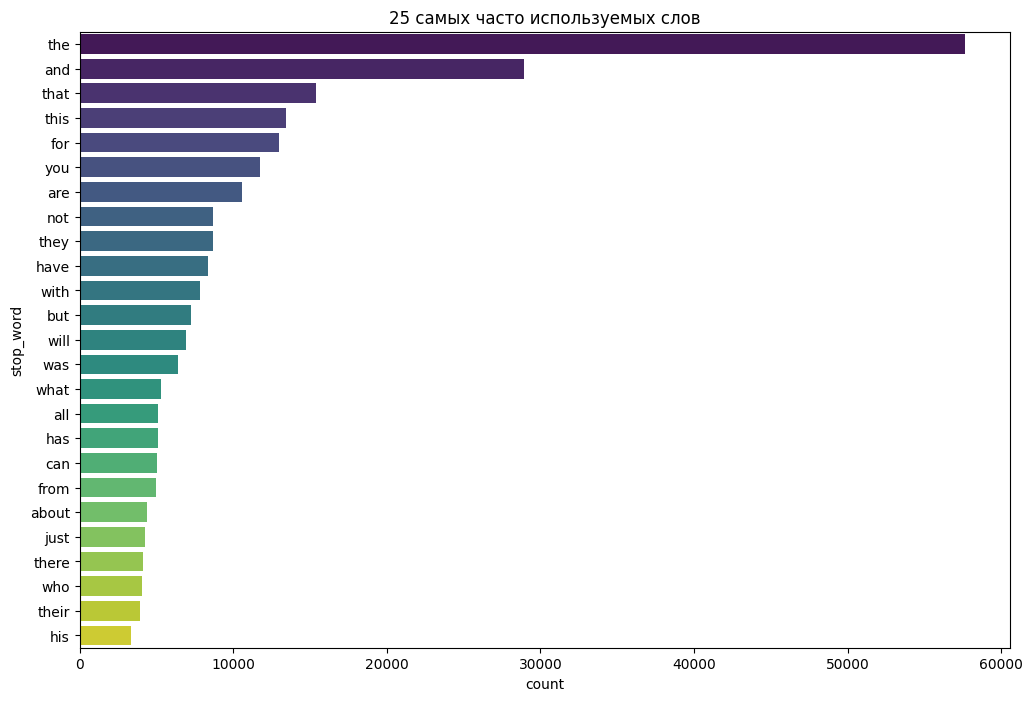

In [92]:
from collections import Counter

all_stop_words = [word for comment in df['clean_comment'] for word in comment.split() if word in stop_words]
most_common_stop_words = Counter(all_stop_words).most_common(25)
top_25_df = pd.DataFrame(most_common_stop_words, columns = ['stop_word', 'count'])
plt.figure(figsize = (12,8))
sns.barplot(data=top_25_df, x='count', y = 'stop_word', palette = 'viridis')
plt.title('25 самых часто используемых слов')
plt.show()

In [93]:
df['num_chars'] = df['clean_comment'].apply(len)
df.head()

,clean_comment,category,word_count,num_stop_words,num_chars
0,family mormon have never tried explain them th...,1,39,13,259
1,buddhism has very much lot compatible with chr...,1,196,59,1268
2,seriously don say thing first all they won get...,-1,86,40,459
3,what you have learned yours and only yours wha...,0,29,15,167
4,for your own benefit you may want read living ...,1,112,45,690


In [94]:
df['num_chars'].describe()

count    36793.000000
mean       181.873753
std        359.848876
min          1.000000
25%         38.000000
50%         80.000000
75%        184.000000
max       8664.000000
Name: num_chars, dtype: float64

In [95]:
from collections import Counter

all_text = ' '.join(df['clean_comment'])
char_frequency = Counter(all_text)
char_frequency_df = pd.DataFrame(char_frequency.items(), columns=['character', 'frequency']).sort_values(by = 'frequency', ascending=False)

In [96]:
char_frequency_df['character'].values

array([' ', 'e', 't', ..., 'پ', 'ڈ', 'ూ'], dtype=object)

In [97]:
char_frequency_df.tail(50)


,character,frequency
1279,闹,1
313,н,1
1313,精,1
1312,耐,1
1311,苦,1
1310,秉,1
1308,剩,1
1307,渣,1
1305,专,1
1304,术,1


In [98]:
df['num_punctuation_chars'] = df['clean_comment'].apply(
    lambda x: sum([1 for char in x if char in '.,!?;:"\'()[]{}~'])
)

df.sample(5)

,clean_comment,category,word_count,num_stop_words,num_chars,num_punctuation_chars
17342,don understand why world leaders would meet wi...,0,14,4,95,0
1838,lyk crie,0,2,0,8,0
2963,for reals though not against nice statue for t...,1,22,10,120,0
19629,the worst part that this isn breaking news for...,-1,11,6,56,0
25170,too many words stop buying shit edit clear eve...,1,72,24,438,0


C:\Users\iblad\AppData\Local\Temp\ipykernel_13568\4024859190.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_25_bigrams_df, x ='count', y = 'bigram', palette='magma')


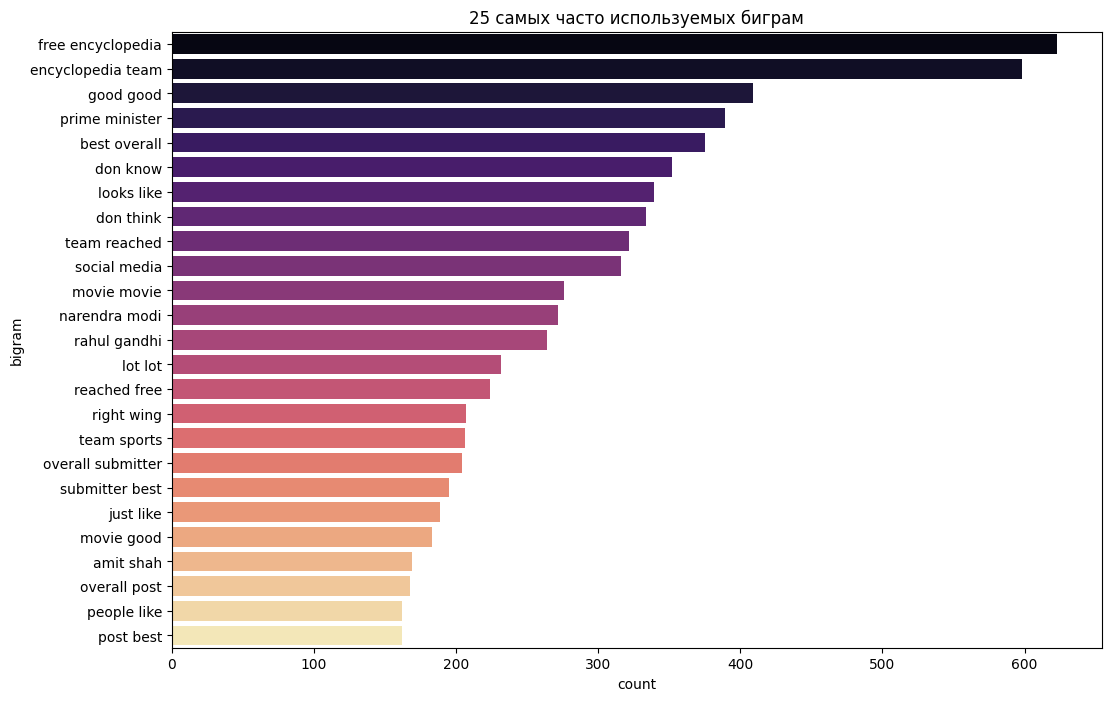

In [99]:
from sklearn.feature_extraction.text import CountVectorizer

def get_top_ngrams(corpus, n = None):
    vec = CountVectorizer(ngram_range=(2,2), stop_words = 'english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis = 0)
    words_freq = [(word, sum_words[0,idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse = True)
    return words_freq[:n]

top_25_bigrams = get_top_ngrams(df['clean_comment'],25)
top_25_bigrams_df = pd.DataFrame(top_25_bigrams, columns = ['bigram', 'count'])

plt.figure(figsize = (12,8))
sns.barplot(data=top_25_bigrams_df, x ='count', y = 'bigram', palette='magma')
plt.title('25 самых часто используемых биграм')
plt.show()

C:\Users\iblad\AppData\Local\Temp\ipykernel_13568\1560211453.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_25_bigrams_df, x ='count', y = 'bigram', palette='magma')


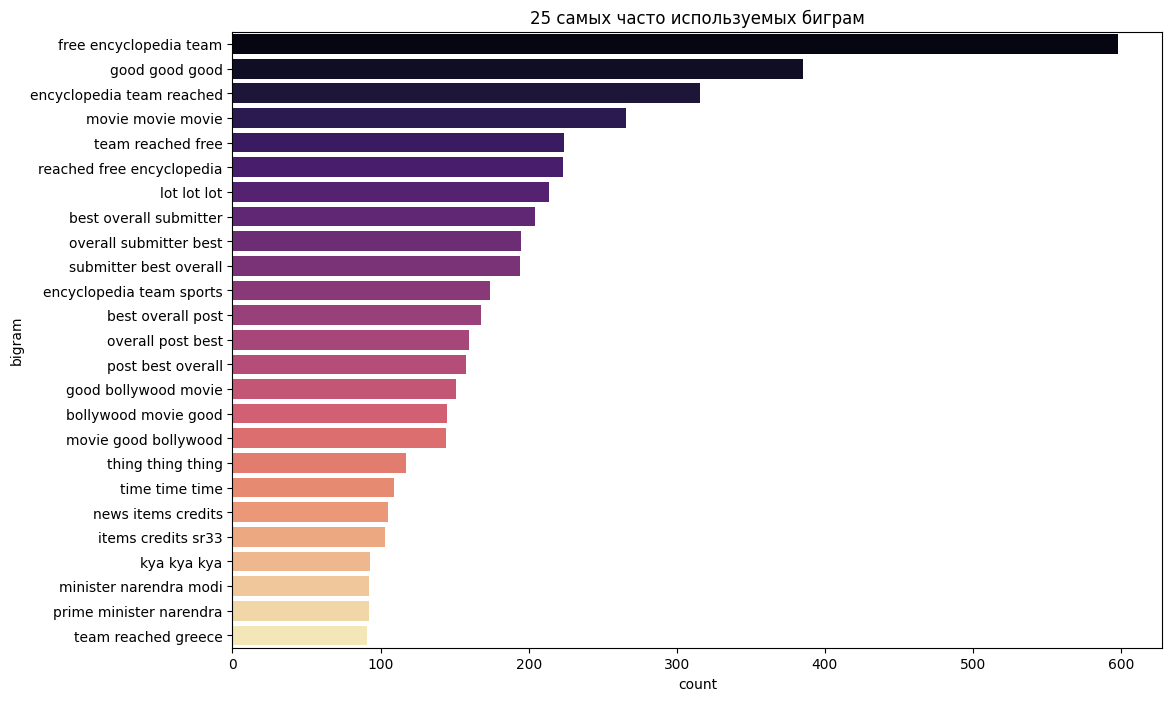

In [100]:
from sklearn.feature_extraction.text import CountVectorizer

def get_top_ngrams(corpus, n = None):
    vec = CountVectorizer(ngram_range=(3,3), stop_words = 'english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis = 0)
    words_freq = [(word, sum_words[0,idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse = True)
    return words_freq[:n]

top_25_bigrams = get_top_ngrams(df['clean_comment'],25)
top_25_bigrams_df = pd.DataFrame(top_25_bigrams, columns = ['bigram', 'count'])

plt.figure(figsize = (12,8))
sns.barplot(data=top_25_bigrams_df, x ='count', y = 'bigram', palette='magma')
plt.title('25 самых часто используемых биграм')
plt.show()

In [106]:
import re

df['clean_comment'] = df['clean_comment'].apply(lambda x: re.sub(r'[^A-Za-z0-9\s!?.,]', '', str(x)))

In [107]:
all_text = ' '.join(df['clean_comment'])
char_frequency = Counter(all_text)
char_frequency_df = pd.DataFrame(char_frequency.items(), columns = ['character', 'frequency']).sort_values(by= 'frequency', ascending=False)
char_frequency_df

,character,frequency
6,,1091668
12,e,666610
13,t,491287
1,a,481134
3,i,401388
9,n,388465
7,o,379908
17,s,355279
8,r,331425
10,h,296748


In [108]:
df

,clean_comment,category,word_count,num_stop_words,num_chars,num_punctuation_chars
0,family mormon have never tried explain them th...,1,39,13,259,0
1,buddhism has very much lot compatible with chr...,1,196,59,1268,0
2,seriously don say thing first all they won get...,-1,86,40,459,0
3,what you have learned yours and only yours wha...,0,29,15,167,0
4,for your own benefit you may want read living ...,1,112,45,690,0
...,...,...,...,...,...,...
37244,jesus,0,1,0,5,0
37245,kya bhai pure saal chutiya banaya modi aur jab...,1,19,0,99,0
37246,downvote karna tha par upvote hogaya,0,6,0,36,0
37247,haha nice,1,2,0,9,0


In [109]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english')) - {'not', 'but', 'however', 'no', 'yet'}

df['clean_comment'] = df['clean_comment'].apply(
    lambda x: ' '.join([word for word in x.split() if word.lower() not in stop_words])
)

In [110]:
df.head()

,clean_comment,category,word_count,num_stop_words,num_chars,num_punctuation_chars
0,family mormon never tried explain still stare ...,1,39,13,259,0
1,buddhism much lot compatible christianity espe...,1,196,59,1268,0
2,seriously say thing first get complex explain ...,-1,86,40,459,0
3,learned want teach different focus goal not wr...,0,29,15,167,0
4,benefit may want read living buddha living chr...,1,112,45,690,0


In [111]:
from nltk.stem import WordNetLemmatizer

nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()

df['clean_comment'] = df['clean_comment'].apply(
    lambda x: ' '.join([lemmatizer.lemmatize(word) for word in x.split()])
)

df.head()

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\iblad\AppData\Roaming\nltk_data...


,clean_comment,category,word_count,num_stop_words,num_chars,num_punctuation_chars
0,family mormon never tried explain still stare ...,1,39,13,259,0
1,buddhism much lot compatible christianity espe...,1,196,59,1268,0
2,seriously say thing first get complex explain ...,-1,86,40,459,0
3,learned want teach different focus goal not wr...,0,29,15,167,0
4,benefit may want read living buddha living chr...,1,112,45,690,0


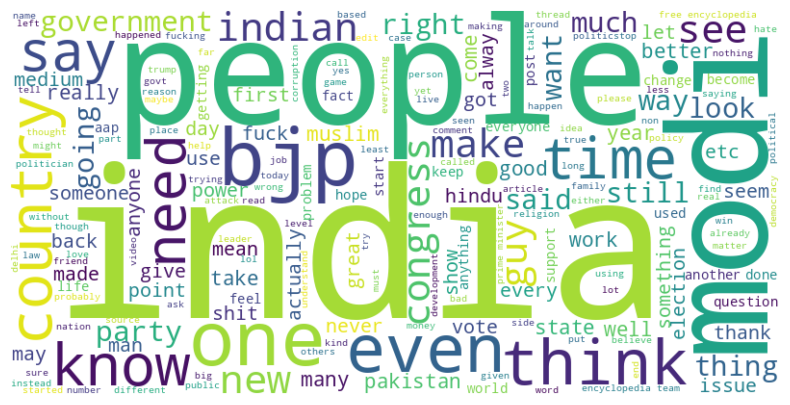

In [112]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def plot_word_cloud(text):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(text))
    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.show()

plot_word_cloud(df['clean_comment'])

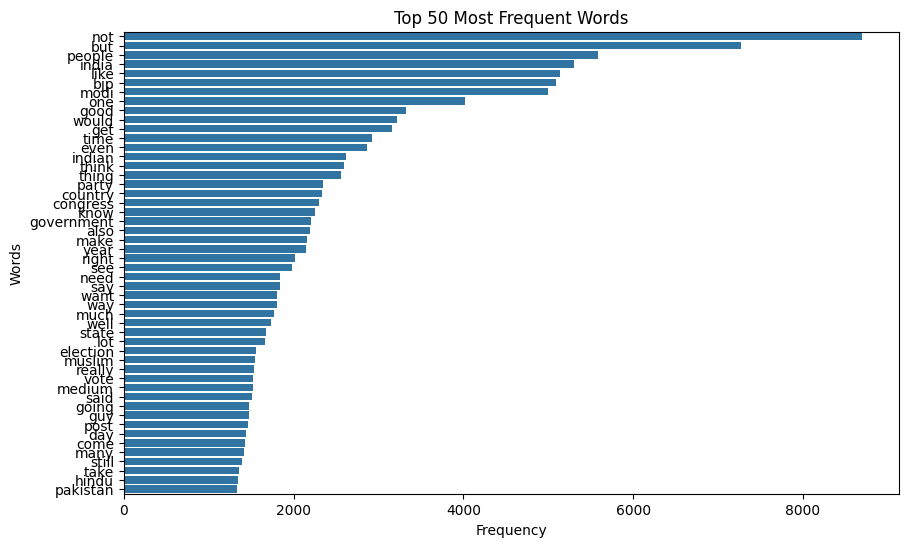

In [ ]:
def plot_top_n_words(df, n=20):
    """Plot the top N most frequent words in the dataset."""
    words = ' '.join(df['clean_comment']).split()

    counter = Counter(words)
    most_common_words = counter.most_common(n)

    words, counts = zip(*most_common_words)

    plt.figure(figsize=(10, 6))
    sns.barplot(x=list(counts), y=list(words))
    plt.title(f'Top {n} Most Frequent Words')
    plt.xlabel('Frequency')
    plt.ylabel('Words')
    plt.show()

plot_top_n_words(df, n=50)

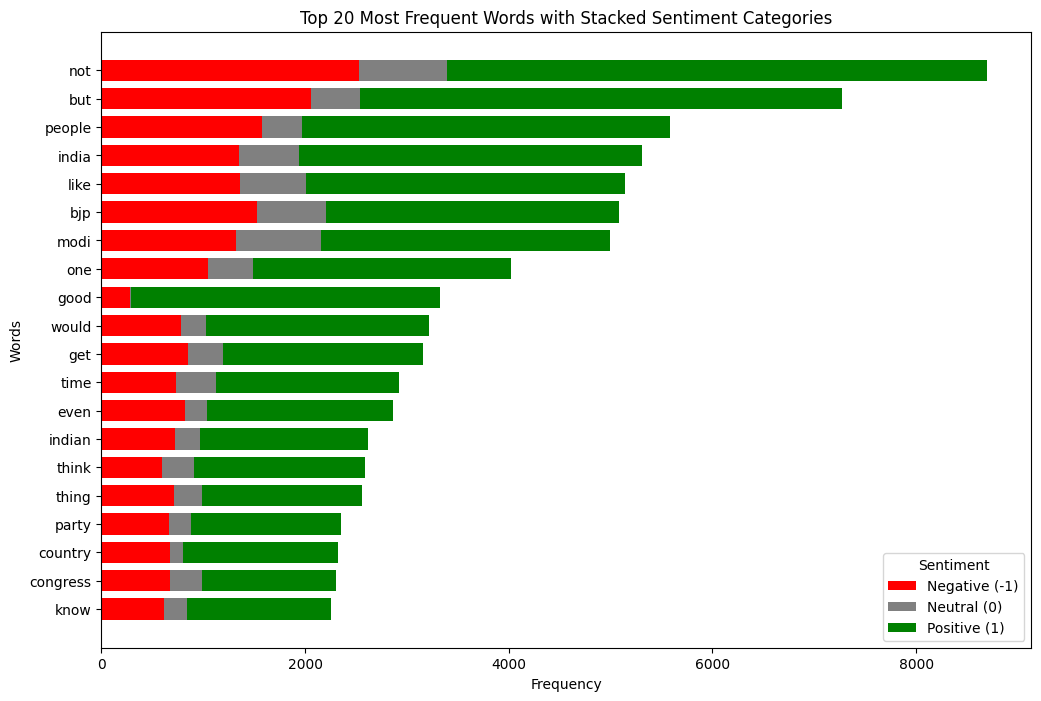

In [ ]:
def plot_top_n_words_by_category(df, n=20, start=0):
    """Plot the top N most frequent words in the dataset with stacked hue based on sentiment category."""
    word_category_counts = {}

    for idx, row in df.iterrows():
        words = row['clean_comment'].split()
        category = row['category'] 
        for word in words:
            if word not in word_category_counts:
                word_category_counts[word] = { -1: 0, 0: 0, 1: 0 }  

            word_category_counts[word][category] += 1

    total_word_counts = {word: sum(counts.values()) for word, counts in word_category_counts.items()}

    most_common_words = sorted(total_word_counts.items(), key=lambda x: x[1], reverse=True)[start:start+n]
    top_words = [word for word, _ in most_common_words]

    word_labels = top_words
    negative_counts = [word_category_counts[word][-1] for word in top_words]
    neutral_counts = [word_category_counts[word][0] for word in top_words]
    positive_counts = [word_category_counts[word][1] for word in top_words]

    plt.figure(figsize=(12, 8))
    bar_width = 0.75

    plt.barh(word_labels, negative_counts, color='red', label='Negative (-1)', height=bar_width)
    plt.barh(word_labels, neutral_counts, left=negative_counts, color='gray', label='Neutral (0)', height=bar_width)
    plt.barh(word_labels, positive_counts, left=[i+j for i,j in zip(negative_counts, neutral_counts)], color='green', label='Positive (1)', height=bar_width)

    plt.xlabel('Frequency')
    plt.ylabel('Words')
    plt.title(f'Top {n} Most Frequent Words with Stacked Sentiment Categories')
    plt.legend(title='Sentiment', loc='lower right')
    plt.gca().invert_yaxis()  
    plt.show()



plot_top_n_words_by_category(df, n=20)